In [118]:
import psycopg2
import os
from pprint import pprint
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Підключення до бази даних

In [119]:
def connect_to_db():
    # Connect DB
    conn = psycopg2.connect(
        dbname = "vendr",
        user = "postgres",
        password = os.getenv('db_password'),
        port = os.getenv('db_port'),
        host = os.getenv('db_host')
    )
    cur = conn.cursor()

    # Return instrument DB
    return conn, cur

## Перевір роботи вивівши 3 елемента

In [120]:
conn, cur = connect_to_db()
cur.execute("""SELECT * FROM products LIMIT 3;""")
db_version = cur.fetchall()
pprint(db_version)

cur.close()

[(97,
  'Commerce and Retail',
  'Analytics and Planning',
  'ChartMogul',
  15.72,
  57.0,
  72.0,
  ''),
 (98,
  'Commerce and Retail',
  'Analytics and Planning',
  'AirDNA?',
  None,
  None,
  None,
  'Gain valuable insights into the performance of 10 million Airbnb & Vrbo '
  "vacation rentals. Analyze the competition's occupancy rates, revenue and "
  'pricing'),
 (99,
  'Commerce and Retail',
  'Analytics and Planning',
  'Baremetrics',
  None,
  None,
  None,
  'Baremetrics is Subscription Analytics and Insights: One click and you get '
  'hundreds of valuable metrics and business insights!')]


## Кількість даних по головній категорії

In [121]:
conn, cur = connect_to_db()
cur.execute("""
SELECT name_main_category, COUNT(*) AS cnt
FROM products
GROUP BY name_main_category
ORDER BY cnt DESC;
""")
db_categories = cur.fetchall()
for db_category in db_categories:
    print(db_category[0],"-",db_category[1])

cur.close()

Vertical Industries - 2616
Data Analytics and Management - 2319
Marketing and Advertising - 1678
Collaboration and Communication - 1395
IT Infrastructure - 1384
Human Resources - 1130
Finance and Accounting - 1073
Commerce and Retail - 1014
DevOps - 891
Security and Compliance - 889
Sales - 864
Productivity - 594
Customer Support - 453


## Кількість даних по дугорідній категорії

In [122]:
conn, cur = connect_to_db()
cur.execute("""SELECT DISTINCT name_main_category,name_uncategory, COUNT(*) as count 
            FROM products
            GROUP BY name_main_category,name_uncategory
            ORDER BY name_main_category
            ;""")

db_uncategories = cur.fetchall()
for db_uncategory in db_uncategories:
    print(db_uncategory[0],"&",db_uncategory[1],"-",db_uncategory[2])
cur.close()

Collaboration and Communication & Appointment Scheduling - 96
Collaboration and Communication & Audio and Transcription - 49
Collaboration and Communication & Calling and VoIP - 94
Collaboration and Communication & Collaboration Suites - 20
Collaboration and Communication & Communication - 112
Collaboration and Communication & Document Management - 161
Collaboration and Communication & Email - 71
Collaboration and Communication & E-Signature - 43
Collaboration and Communication & File Sharing, Storage, Management - 73
Collaboration and Communication & Idea Management - 38
Collaboration and Communication & Knowledge Management - 56
Collaboration and Communication & Language and Translation - 87
Collaboration and Communication & Messaging and Chat - 90
Collaboration and Communication & Team Chat - 1
Collaboration and Communication & Team Collaboration - 204
Collaboration and Communication & Time Tracking - 39
Collaboration and Communication & Video Conferencing - 67
Collaboration and Com

## Кількість Елементів із ціною

In [123]:
conn, cur = connect_to_db()

cur.execute("""SELECT COUNT(*) 
            FROM products
            ;""")
db_all_count = cur.fetchall()
print(db_all_count[0][0])


cur.execute("""SELECT COUNT(*) 
            FROM products
            WHERE min_salary > 0
            ;""")
db_count_salary = cur.fetchall()
pprint(db_count_salary[0][0])
print(round(db_count_salary[0][0]/db_all_count[0][0],4)*100,"% Мають дані про зарплату")
cur.close()

16300
1809
11.1 % Мають дані про зарплату


## Підготовка даних

In [124]:
conn, cur = connect_to_db()
cur.execute("SELECT id, name_main_category, name_uncategory, name_product, min_salary, mad_salary, max_salary, describe FROM products;")
rows = cur.fetchall()
cur.close()

cols = ['id','name_main_category','name_uncategory','name_product','min_salary','mad_salary','max_salary','describe']
df = pd.DataFrame(rows, columns=cols)

for c in ['min_salary','mad_salary','max_salary']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df_any_salary = df.dropna(subset=['min_salary','mad_salary','max_salary'], how='all')


df['has_min'] = df['min_salary'].notna()
df['has_mad'] = df['mad_salary'].notna()
df['has_max'] = df['max_salary'].notna()
df['has_any_salary'] = df[['min_salary','mad_salary','max_salary']].notna().any(axis=1)
df['has_describe'] = df['describe'].astype(str).str.strip().replace({'None':''}).str.len() > 0
df['salary_range'] = np.where(df['min_salary'].notna() & df['max_salary'].notna(),
                              df['max_salary'] - df['min_salary'],
                              np.nan)

### Медіани зарплат за основною категорією

In [125]:
medians_min = df.groupby('name_main_category')['min_salary'].median().sort_values(ascending=False)
pprint(medians_min)

name_main_category
Data Analytics and Management      17.5000
Customer Support                   15.9340
Marketing and Advertising          15.2000
Security and Compliance            15.0000
Commerce and Retail                14.6785
DevOps                             13.2980
Sales                              12.2950
Productivity                       12.0000
IT Infrastructure                  11.8010
Vertical Industries                10.9715
Collaboration and Communication    10.6930
Finance and Accounting             10.4160
Human Resources                     8.0000
Name: min_salary, dtype: float64


### Том категорій для мінімальний цін

In [126]:
pprint(medians_min.dropna().head(10))

name_main_category
Data Analytics and Management    17.5000
Customer Support                 15.9340
Marketing and Advertising        15.2000
Security and Compliance          15.0000
Commerce and Retail              14.6785
DevOps                           13.2980
Sales                            12.2950
Productivity                     12.0000
IT Infrastructure                11.8010
Vertical Industries              10.9715
Name: min_salary, dtype: float64


### Мінімальний вхід в програму

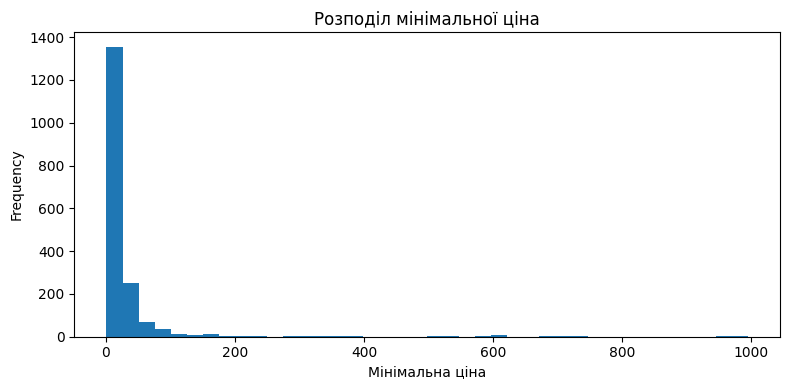

In [127]:
plt.figure(figsize=(8,4))
df['min_salary'].dropna().plot(kind='hist', bins=40)
plt.title('Розподіл мінімальної ціна')
plt.xlabel('Мінімальна ціна')
plt.tight_layout()
plt.show()

### Коробчасті діаграми мінімальної зарплати за N основними категоріями

<Figure size 1200x600 with 0 Axes>

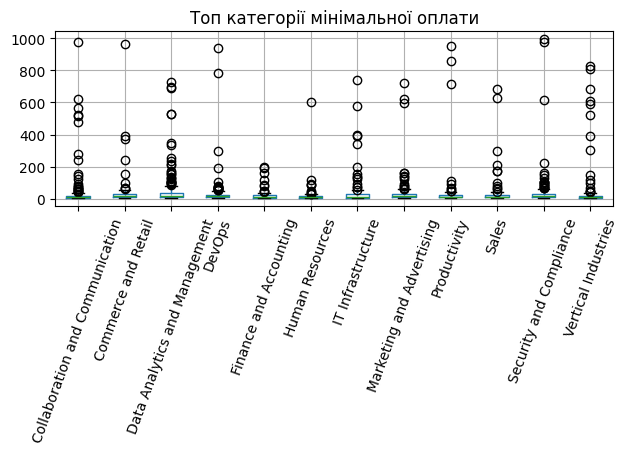

In [132]:
top_cats = df['name_main_category'].value_counts().head(12).index.tolist()
plt.figure(figsize=(12,6))
sns_df = df[df['name_main_category'].isin(top_cats)]
sns_df.boxplot(column='min_salary', by='name_main_category', rot=70)
plt.title('Топ категорії мінімальної оплати')
plt.suptitle('')
plt.xlabel('')
plt.tight_layout()
plt.show()

### Розсіювання: мінімум проти максимуму, де присутні обидва

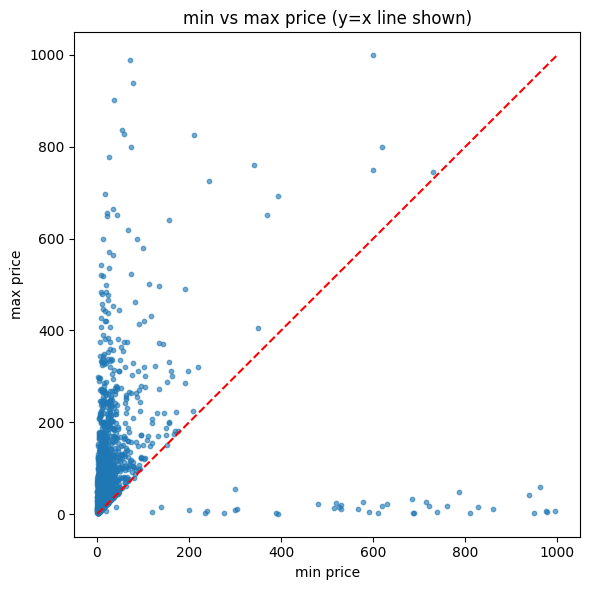

In [129]:
plt.figure(figsize=(6,6))
sub = df.dropna(subset=['min_salary','max_salary'])
plt.scatter(sub['min_salary'], sub['max_salary'], alpha=0.6, s=10)
plt.plot([sub['min_salary'].min(), sub['max_salary'].max()],
         [sub['min_salary'].min(), sub['max_salary'].max()], color='red', linestyle='--')
plt.xlabel('min price'); plt.ylabel('max price')
plt.title('min vs max price (y=x line shown)')
plt.tight_layout()
plt.show()

### Цінові випади

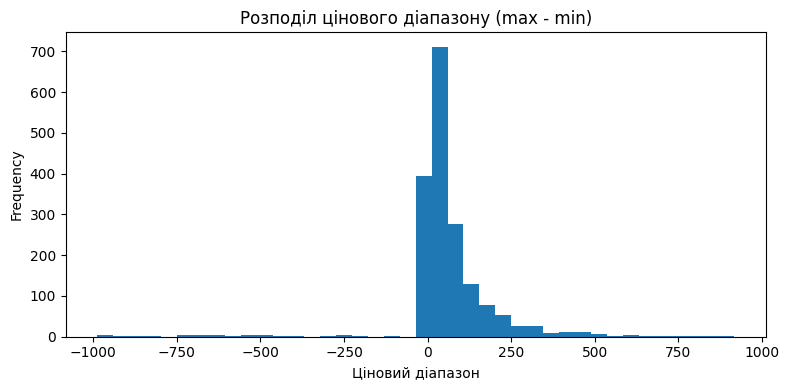

In [130]:
plt.figure(figsize=(8,4))
df['salary_range'].dropna().plot(kind='hist', bins=40)
plt.title('Розподіл цінового діапазону (max - min)')
plt.xlabel('Ціновий діапазон')
plt.tight_layout()
plt.show()

## Сумуємо найбільшу зарплату

In [131]:
pprint({
    'largest_ranges': df[['name_main_category','name_uncategory','name_product','salary_range']].dropna().sort_values('salary_range', ascending=False).head(10).to_dict(orient='records'),
    'products_with_min_and_max': int(df.dropna(subset=['min_salary','max_salary']).shape[0])
})

{'largest_ranges': [{'name_main_category': 'Data Analytics and Management',
                     'name_product': 'AlphaSights',
                     'name_uncategory': 'Business Performance and Consulting',
                     'salary_range': 916.2},
                    {'name_main_category': 'Data Analytics and Management',
                     'name_product': 'Neo4j',
                     'name_uncategory': 'Database Management',
                     'salary_range': 864.1999999999999},
                    {'name_main_category': 'Finance and Accounting',
                     'name_product': 'Allvue Systems?',
                     'name_uncategory': 'Trading and Investing',
                     'salary_range': 861.462},
                    {'name_main_category': 'Marketing and Advertising',
                     'name_product': 'Jornaya',
                     'name_uncategory': 'Marketing Automation',
                     'salary_range': 781.583},
                    {'name_main_catego